# Custom QR

The Custom QR solves the following optimization problem:

$$
\min_{\mathbf{\beta} \in \mathbb{R}^d}
C\sum_{i=1}^n \rho_{\kappa}(y_i-\mathbf{x}_i^\top\mathbf{\beta})
+\frac{1}{2}\|\mathbf{\beta}\|_2^2,
$$

$$
\text{subject to} \quad A\mathbf{\beta}+b \ge 0,
$$

where:

* $\mathbf{x}_i \in \mathbb{R}^d$ is a feature vector
* $y_i \in \mathbb{R}$ is a continuous response variable
* $\rho_{\kappa}(u)=u\big(\kappa-\mathbf{1}(u<0)\big)$ is the quantile (check) loss
* $A \in \mathbb{R}^{K \times d}$ and $b \in \mathbb{R}^{K}$ define custom linear constraints

The custom constraints allow arbitrary prior knowledge (e.g. sign, ordering, budget, or linear relation constraints) to be incorporated into quantile regression.

> **Note.** Since the check loss is a plq function and the constraints are linear ($A\beta+b\ge0$), we can optimize it using `rehline.plq_Ridge_Regressor`.

In [ ]:
## install rehline
%pip install rehline -q

In [2]:
## simulate data
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()

n, d = 10000, 5
X, y = make_regression(n_samples=n, n_features=d, noise=1.0, random_state=42)
X = scaler.fit_transform(X)
y = y / y.std()

In [3]:
# Example: beta_0 + beta_1 >= 3
A = np.zeros((1, d))
A[0, 0] = 1
A[0, 1] = 1
b = np.array([-3.0])

## QR as baseline

In [4]:
## we first run a QR
from rehline import plq_Ridge_Regressor

clf = plq_Ridge_Regressor(
    loss={'name': 'QR', 'qt': 0.5},
    C=1.0,
    max_iter=10000,
    fit_intercept=False
)
clf.fit(X=X, y=y)

plq_Ridge_Regressor(fit_intercept=False, max_iter=10000)

## Custom Constraint

In [5]:
## solve custom via `plq_Ridge_Regressor` by adding `constraint`
from rehline import plq_Ridge_Regressor

cclf = plq_Ridge_Regressor(
    loss={'name': 'QR', 'qt': 0.5},
    constraint=[{'name': 'custom', 'A': A, 'b': b}],
    C=1.0,
    max_iter=10000,
    fit_intercept=False
)
cclf.fit(X=X, y=y)

plq_Ridge_Regressor(constraint=[{'A': array([[1., 1., 0., 0., 0.]]),
                                 'b': array([-3.]), 'name': 'custom'}],
                    fit_intercept=False, max_iter=10000)

In [6]:
import pandas as pd
## score
score = clf.predict(X)
cscore = cclf.predict(X)

qr_perf = np.mean((y - score)**2)
cqr_perf = np.mean((y - cscore)**2)

# Create a pandas DataFrame to store the results
results = pd.DataFrame({
    'Model': ['QR', 'Custom QR'],
    'Train MSE': [qr_perf, cqr_perf]
})

# Print the results as a table
print(results.to_string(index=False))
#Print the results of custom constraint
lhs = cclf.coef_[0] + cclf.coef_[1]
print(f"\ncoef_0 + coef_1 = {lhs:.8f} >= 3: {lhs >= 3}")

    Model  Train MSE
       QR   0.000097
Custom QR   1.352705

coef_0 + coef_1 = 3.00000008 >= 3: True


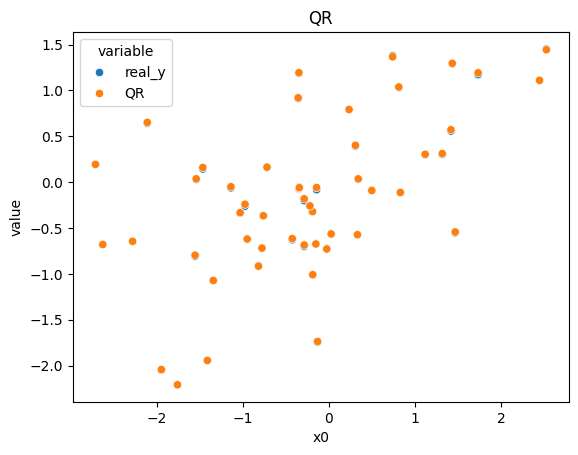

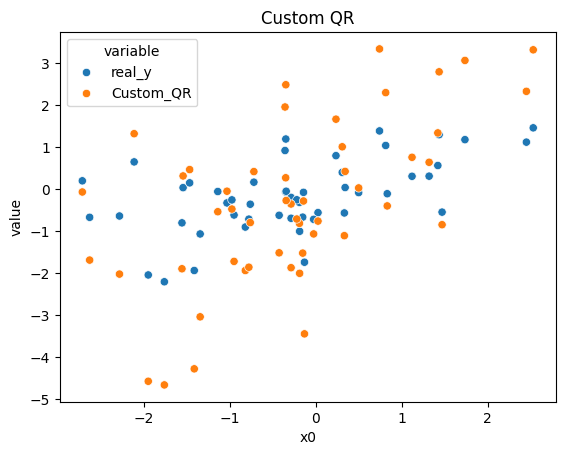

In [7]:
import seaborn as sns
import pandas as pd
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

n_sample = 50
X_sample, y_sample = X[:n_sample], y[:n_sample]
qr_sample = clf.predict(X_sample)
cqr_sample = cclf.predict(X_sample)

df = pd.DataFrame({
    'x0': X_sample[:, 0],
    'real_y': y_sample,
    'QR': qr_sample,
    'Custom_QR': cqr_sample
})

df1 = df[['x0', 'real_y', 'QR']].melt(id_vars='x0')
sns.scatterplot(data=df1, x='x0', y='value', hue='variable').set_title("QR")
plt.show()
df2 = df[['x0', 'real_y', 'Custom_QR']].melt(id_vars='x0')
sns.scatterplot(data=df2, x='x0', y='value', hue='variable').set_title("Custom QR")
plt.show()